This top cell pulls data from the USGS EQ databse as a ".CSV" file. It then transofrms it into and excel file

In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN
import urllib.request


url = "https://earthquake.usgs.gov/fdsnws/event/1/query?format=csv&starttime=1990-01-01&endtime=2026-06-31&minlatitude=32.5&minlongitude=-124.5&maxlatitude=42.0&maxlongitude=-114.1&minmagnitude=4.0"
df = pd.read_csv(url)

coords = df[['latitude', 'longitude']].values

kms_per_radian = 6371.0088
epsilon = 50 / kms_per_radian

db = DBSCAN(eps=epsilon, min_samples=5, metric='haversine').fit(np.radians(coords))

df['Cluster_ID'] = db.labels_

print("Analysis Complete!")

Analysis Complete!


In [2]:
import folium
import pandas as pd
import matplotlib.pyplot as plt


map_center = [df['latitude'].mean(), df['longitude'].mean()]
earthquake_map = folium.Map(location=map_center, zoom_start=5)

cluster_colors = {-1: 'gray', 0: 'red', 1: 'blue', 2: 'green', 3: 'purple', 4: 'orange', 5: 'darkred'}

for _, row in df.iterrows():
    c_id = row['Cluster_ID']
    color_val = cluster_colors.get(c_id, 'black')

    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=5,
        color=color_val,
        fill=True,
        fill_color=color_val,
        fill_opacity=0.7,
        popup=f"Cluster: {c_id}<br>Magnitude: {row.get('mag', 'N/A')}"
    ).add_to(earthquake_map)


# extract just the rows with Mag >= 6M, style them larger and give them a distinctive 'salmon' hue
major_events = df[df['mag'] >= 6.0]

for _, row in major_events.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=10,
        color='brown',
        fill=True,
        fill_color='hotpink',
        fill_opacity=0.9,
        weight=2,
        popup=f"<b>CRITICAL EVENT</b><br>Magnitude: {row['mag']}<br>Cluster: {row['Cluster_ID']}"
    ).add_to(earthquake_map)


cluster_counts = df['Cluster_ID'].value_counts()


legend_html = f"""
<div style="
    position: fixed;
    bottom: 30px; right: 30px; width: 180px; height: auto;
    background-color: white; z-index:9999; font-size:14px;
    padding: 10px; border: 2px solid grey; border-radius: 5px;
    box-shadow: 0 0 15px rgba(0,0,0,0.2);">
    <b>DBSCAN Legend</b><br>
    <i style="background:red; width:12px; height:12px; float:left; margin-right:8px; border-radius:50%;"></i> Cluster 0 ({cluster_counts.get(0, 0)})<br>
    <i style="background:blue; width:12px; height:12px; float:left; margin-right:8px; border-radius:50%;"></i> Cluster 1 ({cluster_counts.get(1, 0)})<br>
    <i style="background:green; width:12px; height:12px; float:left; margin-right:8px; border-radius:50%;"></i> Cluster 2 ({cluster_counts.get(2, 0)})<br>
    <i style="background:purple; width:12px; height:12px; float:left; margin-right:8px; border-radius:50%;"></i> Cluster 3 ({cluster_counts.get(3, 0)})<br>
    <i style="background:orange; width:12px; height:12px; float:left; margin-right:8px; border-radius:50%;"></i> Cluster 4 ({cluster_counts.get(4, 0)})<br>
    <i style="background:darkred; width:12px; height:12px; float:left; margin-right:8px; border-radius:50%;"></i> Cluster 5 ({cluster_counts.get(5, 0)})<br>
    <i style="background:gray; width:12px; height:12px; float:left; margin-right:8px; border-radius:50%;"></i> Noise (-1) ({cluster_counts.get(-1, 0)})<br>
    <hr style="margin: 8px 0;">
    <i style="background:hotpink; width:14px; height:14px; float:left; margin-right:8px; border-radius:50%; border: 1px solid brown;"></i> <b>Mag \u2265 6.0 Event</b><br>
</div>
"""

earthquake_map.get_root().html.add_child(folium.Element(legend_html))

earthquake_map

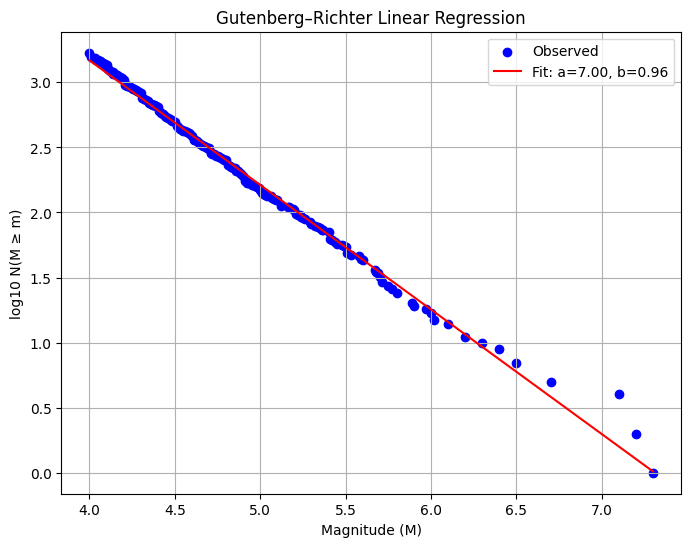

In [3]:
import numpy as np
import pandas as pd

bins = np.sort(df['mag'].unique())

gr_table = []

for m in bins:
    N = (df['mag'] >= m).sum()
    if N > 0:
        gr_table.append([m, N, np.log10(N)])

gr_df = pd.DataFrame(gr_table, columns=['magnitude', 'N', 'log10N'])

from sklearn.linear_model import LinearRegression

X = gr_df[['magnitude']]
y = gr_df['log10N']

model = LinearRegression().fit(X, y)

b_value = -model.coef_[0]
a_value = model.intercept_


plt.figure(figsize=(8,6))

# Scatter points
plt.scatter(gr_df['magnitude'], gr_df['log10N'], color='blue', label='Observed')

# Regression line
m_vals = np.linspace(gr_df['magnitude'].min(), gr_df['magnitude'].max(), 100)
logN_pred = a_value - b_value * m_vals

plt.plot(m_vals, logN_pred, color='red', label=f'Fit: a={a_value:.2f}, b={b_value:.2f}')

plt.xlabel('Magnitude (M)')
plt.ylabel('log10 N(M ≥ m)')
plt.title('Gutenberg–Richter Linear Regression')
plt.legend()
plt.grid(True)
plt.show()


In [4]:
import numpy as np
from sklearn.linear_model import LinearRegression
from matplotlib import colormaps
import matplotlib.colors as colors
import pandas as pd
import folium

cluster_results = []

# Loop through each cluster except noise (-1)
for cluster_id in sorted(df['Cluster_ID'].unique()):
    if cluster_id == -1:
        continue  # skip noise

    cluster_df = df[df['Cluster_ID'] == cluster_id]

    mags = np.sort(cluster_df['mag'].values)

    N = np.array([np.sum(mags >= m) for m in mags])

    logN = np.log10(N)

    X = mags.reshape(-1, 1)
    y = logN

    # Fit linear regression
    model = LinearRegression()
    model.fit(X, y)

    a_value = model.intercept_
    b_value = -model.coef_[0]  # negative slope

    cluster_results.append({
        "Cluster_ID": cluster_id,
        "a_value": a_value,
        "b_value": b_value,
        "num_quakes": len(cluster_df)
    })

gr_df = pd.DataFrame(cluster_results)

cluster_results_dict = {item['Cluster_ID']: item for item in cluster_results}

b_vals = [item['b_value'] for item in cluster_results]
norm = colors.Normalize(vmin=min(b_vals), vmax=max(b_vals))
cmap = colormaps['turbo']

bvalue_colors = {
    cid: colors.to_hex(cmap(norm(item['b_value'])))
    for cid, item in cluster_results_dict.items()
}

map_center = [df['latitude'].mean(), df['longitude'].mean()]
earthquake_map = folium.Map(location=map_center, zoom_start=5)

for _, row in df.iterrows():
    cid = row['Cluster_ID']

    if cid == -1:
        color_val = 'gray'  # noise
    else:
        color_val = bvalue_colors.get(cid, 'black')

    # Conditionally format b-value for popup
    b_value_for_popup = cluster_results_dict.get(cid, {}).get('b_value', 'N/A')
    if isinstance(b_value_for_popup, (float, np.floating)): # Check if it's a numeric type
        b_value_str = f"{b_value_for_popup:.2f}"
    else:
        b_value_str = b_value_for_popup

    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=5,
        color=color_val,
        fill=True,
        fill_color=color_val,
        fill_opacity=0.7,
        popup=f"Cluster: {cid}<br>Magnitude: {row.get('mag', 'N/A')}<br>b-value: {b_value_str}"
    ).add_to(earthquake_map)

legend_html = """
<div style="
    position: fixed;
    bottom: 30px; left: 30px; width: 220px;
    background-color: white; z-index:9999; font-size:14px;
    padding: 10px; border: 2px solid grey; border-radius: 5px;">
    <b>b-value Legend</b><br>
    <i>Color = b-value (Gutenberg–Richter)</i><br><br>
"""

for cid, item in cluster_results_dict.items():
    bv = item['b_value']
    legend_html += f"""
    <div>
        <span style="background:{bvalue_colors[cid]};
                     width:12px; height:12px;
                     display:inline-block;
                     margin-right:8px;"></span>
        Cluster {cid}: b = {bv:.2f}
    </div>
    """

legend_html += "</div>"


b_lookup = dict(zip(gr_df['Cluster_ID'], gr_df['b_value']))
a_lookup = dict(zip(gr_df['Cluster_ID'], gr_df['a_value']))

bvalue_map = folium.Map(location=map_center, zoom_start=5)

cmap = colormaps['turbo']

b_colors = {
    cid: colors.to_hex(cmap(norm(bv)))
    for cid, bv in b_lookup.items()
}

for _, row in df.iterrows():
    cid = row['Cluster_ID']

    if cid == -1:
        color_val = 'gray'   # noise
    else:
        color_val = b_colors.get(cid, 'black')

    b_value_for_popup_bmap = b_lookup.get(cid, 'N/A')
    if isinstance(b_value_for_popup_bmap, (float, np.floating)):
        b_value_str_bmap = f"{b_value_for_popup_bmap:.3f}"
    else:
        b_value_str_bmap = b_value_for_popup_bmap

    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=5,
        color=color_val,
        fill=True,
        fill_color=color_val,
        fill_opacity=0.7,
        popup=(
            f"Cluster: {cid}<br>"
            f"Magnitude: {row['mag']}<br>"
            f"b-value: {b_value_str_bmap}"
        )
    ).add_to(bvalue_map)

legend_html = """
<div style="
    position: fixed;
    bottom: 30px; left: 30px; width: 260px;
    background-color: white; z-index:9999; font-size:14px;
    padding: 10px; border: 2px solid grey; border-radius: 5px;">
    <b>Gutenberg–Richter Parameters</b><br>
    <i>Cluster a- and b-values</i><br><br>
"""


for cid, bv in b_lookup.items():
    av = a_lookup.get(cid)

    legend_html += f"""
    <div>
        <span style="background:{b_colors[cid]};
                     width:12px; height:12px;
                     display:inline-block;
                     margin-right:8px;"></span>
        Cluster {cid}: b = {bv:.2f}, a = {av:.2f}
    </div>
    """

legend_html += "</div>"

bvalue_map.get_root().html.add_child(folium.Element(legend_html))

bvalue_map